In [22]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA , NVIDIAEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document

from langgraph.graph import StateGraph , START , END

from dotenv import load_dotenv
from pydantic import BaseModel , Field
from typing import TypedDict , List , Literal

import time

In [23]:
load_dotenv()

True

In [24]:
docs = (

    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Policies.pdf').load() + 
    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Profile.pdf').load() + 
    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Policies.pdf').load()
)

In [25]:
# Text splitting
chunk = RecursiveCharacterTextSplitter(chunk_size = 600 , chunk_overlap = 150).split_documents(docs)

In [26]:
embedding = NVIDIAEmbeddings()
vector_store = FAISS.from_documents(chunk , embedding)
retriever = vector_store.as_retriever(search_kwargs = {'k' : 4})

In [27]:
llm = ChatNVIDIA(model = 'openai/gpt-oss-120b')

In [37]:
# Define state
class State(TypedDict):
    question : str
    need_retrieval : bool
    docs : List[Document]
    answer : str
    relavent_docs : List[Document]

In [38]:
class RetrieverDecision(BaseModel):
    should_retrieve : bool = Field(... , description='True if external documents are needed to answer relaibly, else False')


decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'You decide whether retrieval is needed.\n'
            'Return JSON that matches this schema:\n'
            '{{should_retrieve : boolan}}\n\n'
            'Guidelines:\n'
            '- Should_retrieve=True if answering requires specific facts, citations , info likely not in the model.\n'
            '- Should_retrieve=False for general explanations , definations, or reasoning that does not need source.\n'
            '- If unsure , choose True'
        ),
        ('human' , 'Question : {question}'),
    ]
)

# IMPORTANT : no content for structure output
should_retrieve_llm = llm.with_structured_output(RetrieverDecision)


def decide_retrieval(state : State):

    decision : RetrieverDecision = should_retrieve_llm.invoke(

        decide_retrieval_prompt.format_messages(question= state['question'])
    )

    return {'need_retrieval' : decision.should_retrieve}

In [ ]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'Answer the question using only your general knowledge.\n'
            'Do NOT assume access to external documents.\n'
            'If you unsure or the answer require specific sources, say:\n'
            'I do not know based on my general knowledge.'
        ),
        ('human' , '{question}')
    ]
)

def generate_direct(state : State):

    out = llm.invoke(

        direct_generation_prompt.format_messages(question = state['question'])
    )

    return {'answer' : out.content}

In [40]:
def retrieve(state : State):

    return {'docs' : retriever.invoke(state['question'])}

In [41]:
class RelavenceDecision(BaseModel):

    is_relevant : bool = Field(... , description='True if the documnent helps answer the question , else False')

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'You are judging document relevance.\n'
            'Return JSON that matches this schema.\n'
            '{{is_relevant : boolean}}\n\n'
            'A document is relevant if it contains information useful for answering the question.\n'
        ),
        ('human' , 'Question : \n{question}\n\nDocument : \n {document}')
    ]
)

relevance_llm = llm.with_structured_output(RelavenceDecision)

def is_relevant(state : State):

    relevant_doc : List[Document] = []

    for doc in state['docs']:

        decision : RelavenceDecision = relevance_llm.invoke(

            is_relevant_prompt.format_messages(
                question = state['question'],
                document = doc.page_content
            )
        )


        if decision.is_relevant:
            relevant_doc.append(doc)


    return {'relevant_doc' : relevant_doc}

In [45]:
def route_after_decide(state : State) -> Literal['generate_direct' , 'retrieve']:

    if state['need_retrieval']:
        return 'retrieve'
    
    else:
        return 'generate_direct'

In [46]:
builder = StateGraph(State)

# Add nodes
builder.add_node('decide_retrieval' , decide_retrieval)
builder.add_node('generate_direct' , generate_direct)
builder.add_node('is_relevant' , is_relevant)
builder.add_node('retrieve' , retrieve)

# Add edges
builder.add_edge(START, "decide_retrieval")

builder.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

builder.add_edge("generate_direct", END)
builder.add_edge("retrieve", "is_relevant") # New
builder.add_edge("is_relevant", END) # New

# compile the graph

app = builder.compile()

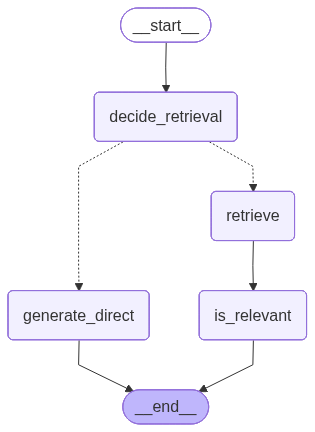

In [47]:
app

In [48]:
result = app.invoke(
    {
        "question": "Who is the CEO of NexaAI",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

In [49]:
result['need_retrieval']

True

In [50]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships
****************************************************************************************************
NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations acros

In [52]:
result

{'question': 'Who is the CEO of NexaAI',
 'need_retrieval': True,
 'docs': [Document(id='f1ce58c8-d698-4fd1-9152-ae5a0ece4a95', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'D:\\GenAI\\LangGraph\\document\\Company_Profile.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='Founder\nAarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and\ncloud infrastructure.\nHe previously worked with global consulting firms where he led multiple large-scale digital\ntransformation projects.\nLeadership Team\nThe leadership team brings experience across AI engineering, product management, and business\noperations.\n\x7f\nAarav Mehta – CEO & Founder\n\x7f\nRiya Kapoor – CTO (Distributed systems